## 1. Data loading / setup

In [1]:
!pip install duckdb pandas matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Yunhui Dong\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import duckdb
import pandas as pd
import time
import matplotlib.pyplot as plt

In [ ]:
con = duckdb.connect("../data/supermarket.duckdb")

In [7]:
csv_file = "SuperMarket Analysis.csv"

con.execute(f"""
CREATE OR REPLACE TABLE supermarket_sales AS
SELECT
    "Invoice ID" AS invoice_id,
    Branch AS branch,
    City AS city,
    "Customer type" AS customer_type,
    Gender AS gender,
    "Product line" AS product_line,
    "Unit price" AS unit_price,
    Quantity AS quantity,
    "Tax 5%" AS tax_5_percent,
    Sales AS sales,
    CAST(Date AS DATE) AS sale_date,
    CAST(Time AS TIME) AS sale_time,
    Payment AS payment,
    cogs AS cogs,
    "gross margin percentage" AS gross_margin_percentage,
    "gross income" AS gross_income,
    Rating AS rating
FROM read_csv_auto('{csv_file}', header=True);
""")

In [8]:
con.execute("SELECT * FROM supermarket_sales LIMIT 5").df()

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5_percent,sales,sale_date,sale_time,payment,cogs,gross_margin_percentage,gross_income,rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,01:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,01:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,08:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


In [9]:
con.execute("SELECT COUNT(*) AS row_count FROM supermarket_sales").df()

,row_count
0,1000


## 2. Analytical operations

In [10]:
q1 = """
SELECT city, SUM(sales) AS total_sales
FROM supermarket_sales
GROUP BY city
ORDER BY total_sales DESC;
"""

df_q1 = con.execute(q1).df()
df_q1

,city,total_sales
0,Naypyitaw,110568.7065
1,Yangon,106200.3705
2,Mandalay,106197.6720


In [ ]:
q2 = """
SELECT product_line, AVG(sales) AS avg_sales
FROM supermarket_sales
GROUP BY product_line
ORDER BY avg_sales DESC;
"""

df_q2 = con.execute(q2).df()
df_q2

,product_line,avg_sales
0,Home and lifestyle,336.636956
1,Sports and travel,332.065220
2,Health and beauty,323.643020
3,Food and beverages,322.671517
4,Electronic accessories,319.632538
5,Fashion accessories,305.089298


In [ ]:
q3 = """
SELECT SUM(sales) AS jan_sales
FROM supermarket_sales
WHERE sale_date BETWEEN DATE '2019-01-01' AND DATE '2019-01-31';
"""

df_q3 = con.execute(q3).df()
df_q3

,jan_sales
0,116291.868


In [13]:
q4 = """
SELECT payment,
       COUNT(*) AS num_transactions,
       SUM(sales) AS total_sales
FROM supermarket_sales
GROUP BY payment
ORDER BY total_sales DESC;
"""

df_q4 = con.execute(q4).df()
df_q4

,payment,num_transactions,total_sales
0,Cash,344,112206.570
1,Ewallet,345,109993.107
2,Credit card,311,100767.072


In [14]:
q5 = """
SELECT branch,
       product_line,
       SUM(sales) AS total_sales
FROM supermarket_sales
GROUP BY branch, product_line
ORDER BY branch, total_sales DESC;
"""

df_q5 = con.execute(q5).df()
df_q5

,branch,product_line,total_sales
0,Alex,Home and lifestyle,22417.1955
1,Alex,Sports and travel,19372.6995
2,Alex,Electronic accessories,18317.1135
3,Alex,Food and beverages,17163.1005
4,Alex,Fashion accessories,16332.5085
5,Alex,Health and beauty,12597.7530
6,Cairo,Sports and travel,19988.1990
7,Cairo,Health and beauty,19980.6600
8,Cairo,Home and lifestyle,17549.1645
9,Cairo,Electronic accessories,17051.4435


## 3. Internal inspection

In [15]:
plan_q1 = con.execute(f"EXPLAIN {q1}").fetchone()[1]
print(plan_q1)

┌───────────────────────────┐
│         PROJECTION        │
│    ────────────────────   │
│__internal_decompress_strin│
│           g(#0)           │
│             #1            │
│                           │
│          ~0 rows          │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│          ORDER_BY         │
│    ────────────────────   │
│    sum(supermarket.main   │
│ .supermarket_sales.sales) │
│            DESC           │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│__internal_compress_string_│
│        uhugeint(#0)       │
│             #1            │
│                           │
│          ~3 rows          │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│__internal_decompress_strin│
│           g(#0)           │
│             #1            │
│                           │
│          ~3 rows          │
└─────────

In [16]:
analyze_q3 = con.execute(f"EXPLAIN ANALYZE {q3}").fetchone()[1]
print(analyze_q3)

┌─────────────────────────────────────┐
│┌───────────────────────────────────┐│
││    Query Profiling Information    ││
│└───────────────────────────────────┘│
└─────────────────────────────────────┘
EXPLAIN ANALYZE  SELECT SUM(sales) AS jan_sales FROM supermarket_sales WHERE sale_date BETWEEN DATE '2019-01-01' AND DATE '2019-01-31'; 
┌────────────────────────────────────────────────┐
│┌──────────────────────────────────────────────┐│
││              Total Time: 0.0018s             ││
│└──────────────────────────────────────────────┘│
└────────────────────────────────────────────────┘
┌───────────────────────────┐
│           QUERY           │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│      EXPLAIN_ANALYZE      │
│    ────────────────────   │
│                           │
│           0 rows          │
│           0.00s           │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│    UNGROUPED_AGGREGATE    │
│    ────────────────────   │
│    Aggregates: s

In [17]:
print("""
Operation 1: Total sales by city
- Application does: summarize total sales for each city.
- Database does internally: scans relevant columns (city, sales), then performs grouped aggregation.
- Why it matters: shows how analytical queries benefit from columnar access and aggregation-friendly execution.
""")


Operation 1: Total sales by city
- Application does: summarize total sales for each city.
- Database does internally: scans relevant columns (city, sales), then performs grouped aggregation.
- Why it matters: shows how analytical queries benefit from columnar access and aggregation-friendly execution.



## 4. Validation / experiment

In [18]:
con.execute("""
CREATE OR REPLACE TABLE supermarket_sales_10x AS
SELECT * FROM supermarket_sales
CROSS JOIN range(10);
""")

In [19]:
con.execute("""
CREATE OR REPLACE TABLE supermarket_sales_100x AS
SELECT * FROM supermarket_sales
CROSS JOIN range(100);
""")

In [20]:
con.execute("""
SELECT 'original' AS dataset, COUNT(*) AS rows FROM supermarket_sales
UNION ALL
SELECT '10x' AS dataset, COUNT(*) AS rows FROM supermarket_sales_10x
UNION ALL
SELECT '100x' AS dataset, COUNT(*) AS rows FROM supermarket_sales_100x;
""").df()

,dataset,rows
0,original,1000
1,10x,10000
2,100x,100000


In [21]:
perf_queries = {
    "sales_by_city": """
        SELECT city, SUM(sales) AS total_sales
        FROM {table_name}
        GROUP BY city
    """,
    
    "avg_sales_by_product": """
        SELECT product_line, AVG(sales) AS avg_sales
        FROM {table_name}
        GROUP BY product_line
    """,
    
    "january_sales": """
        SELECT SUM(sales) AS jan_sales
        FROM {table_name}
        WHERE sale_date BETWEEN DATE '2019-01-01' AND DATE '2019-01-31'
    """
}

In [22]:
def time_query(con, query, runs=5):
    times = []
    for _ in range(runs):
        start = time.perf_counter()
        con.execute(query).fetchall()
        end = time.perf_counter()
        times.append(end - start)
    return sum(times) / len(times)

In [23]:
tables = ["supermarket_sales", "supermarket_sales_10x", "supermarket_sales_100x"]

results = []

for table in tables:
    for query_name, query_template in perf_queries.items():
        query = query_template.format(table_name=table)
        avg_time = time_query(con, query, runs=5)
        results.append({
            "table": table,
            "query": query_name,
            "avg_time_sec": avg_time
        })

perf_df = pd.DataFrame(results)
perf_df

,table,query,avg_time_sec
0,supermarket_sales,sales_by_city,0.005016
1,supermarket_sales,avg_sales_by_product,0.001540
2,supermarket_sales,january_sales,0.001316
3,supermarket_sales_10x,sales_by_city,0.000943
4,supermarket_sales_10x,avg_sales_by_product,0.001218
5,supermarket_sales_10x,january_sales,0.000410
6,supermarket_sales_100x,sales_by_city,0.001155
7,supermarket_sales_100x,avg_sales_by_product,0.001945
8,supermarket_sales_100x,january_sales,0.002141


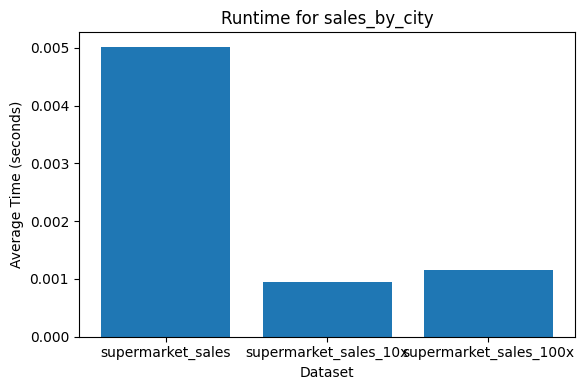

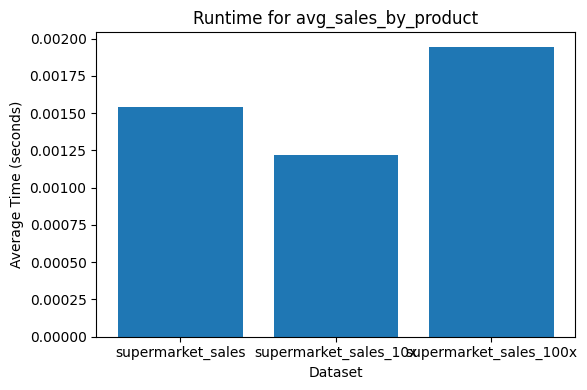

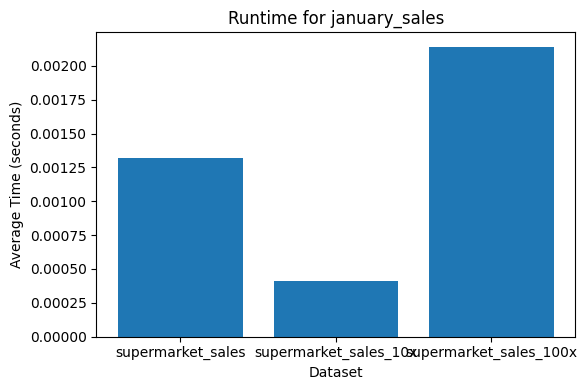

In [24]:
for query_name in perf_df["query"].unique():
    temp = perf_df[perf_df["query"] == query_name]
    
    plt.figure(figsize=(6,4))
    plt.bar(temp["table"], temp["avg_time_sec"])
    plt.title(f"Runtime for {query_name}")
    plt.xlabel("Dataset")
    plt.ylabel("Average Time (seconds)")
    plt.tight_layout()
    plt.show()

In [25]:
query_select_few = """
SELECT city, SUM(sales)
FROM supermarket_sales_100x
GROUP BY city
"""

query_select_all = """
SELECT *
FROM supermarket_sales_100x
"""

few_time = time_query(con, query_select_few, runs=5)
all_time = time_query(con, query_select_all, runs=5)

print("Grouped query using needed columns only:", few_time)
print("SELECT * full table scan:", all_time)

Grouped query using needed columns only: 0.017151960008777677
SELECT * full table scan: 0.24676717998227105


In [26]:
con.close()